In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/earthquakes.csv')

# See the first 5 rows
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (23412, 21)


,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [ ]:
# Check column names
print(df.columns.tolist())

['Date', 'Time', 'Latitude', 'Longitude', 'Type', 'Depth', 'Depth Error', 'Depth Seismic Stations', 'Magnitude', 'Magnitude Type', 'Magnitude Error', 'Magnitude Seismic Stations', 'Azimuthal Gap', 'Horizontal Distance', 'Horizontal Error', 'Root Mean Square', 'ID', 'Source', 'Location Source', 'Magnitude Source', 'Status']


In [ ]:
# Keep only what we need
df = df[['Latitude', 'Longitude', 'Magnitude', 'Depth']].dropna()
print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (23412, 4)


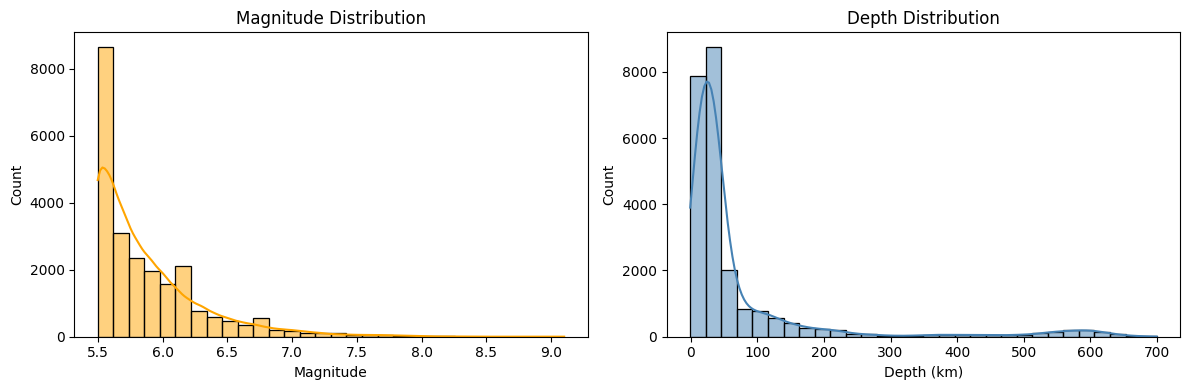

In [ ]:
# EDA: Distribution of Magnitude
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Magnitude'], bins=30, color='orange', kde=True)
plt.title('Magnitude Distribution')
plt.xlabel('Magnitude')

plt.subplot(1, 2, 2)
sns.histplot(df['Depth'], bins=30, color='steelblue', kde=True)
plt.title('Depth Distribution')
plt.xlabel('Depth (km)')

plt.tight_layout()
plt.show()

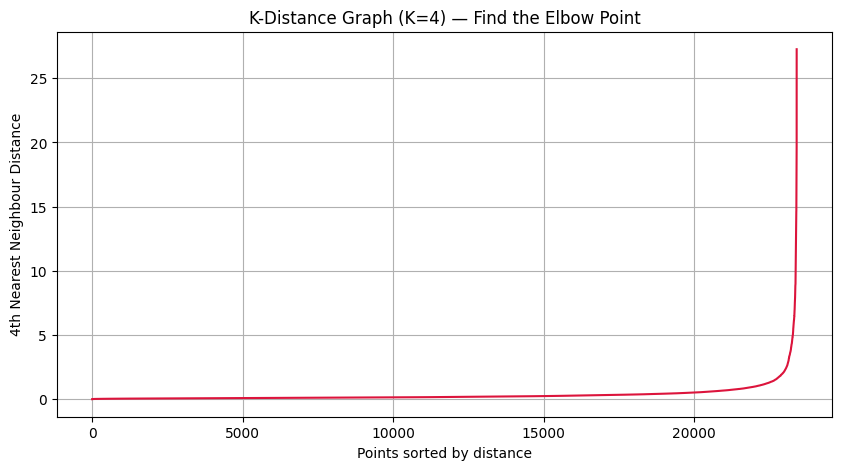

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Use only Latitude and Longitude
coords = df[['Latitude', 'Longitude']].values

# Find distance to the 4th nearest neighbour for each point
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(coords)
distances, indices = neighbors_fit.kneighbors(coords)

# Sort distances and plot
distances = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances, color='crimson')
plt.title('K-Distance Graph (K=4) — Find the Elbow Point')
plt.xlabel('Points sorted by distance')
plt.ylabel('4th Nearest Neighbour Distance')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
# epsilon = 3 (adjust based on your elbow graph)
# min_samples = 5 (minimum points to form a cluster)
db = DBSCAN(eps=3, min_samples=5)
df['DBSCAN_Cluster'] = db.fit_predict(coords)

# -1 = noise points (isolated earthquakes)
n_clusters = len(set(df['DBSCAN_Cluster'])) - 1  # subtract noise label (-1)
n_noise = (df['DBSCAN_Cluster'] == -1).sum()

print(f"✅ Number of clusters found: {n_clusters}")
print(f"⚠️  Number of noise points (isolated quakes): {n_noise}")

✅ Number of clusters found: 66
⚠️  Number of noise points (isolated quakes): 266


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


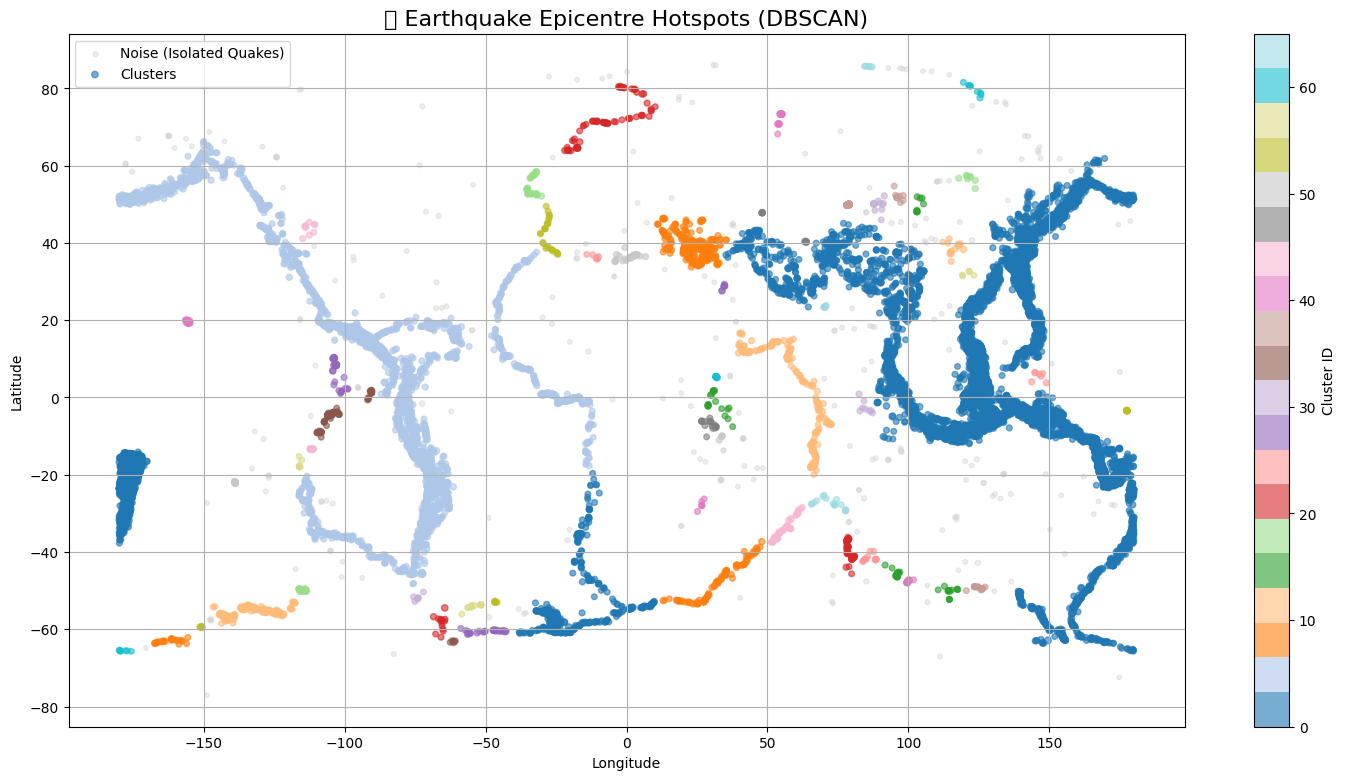

In [ ]:
plt.figure(figsize=(18, 9))

# Separate noise and clusters
noise = df[df['DBSCAN_Cluster'] == -1]
clusters = df[df['DBSCAN_Cluster'] != -1]

# Plot noise points (grey)
plt.scatter(noise['Longitude'], noise['Latitude'],
            c='lightgrey', s=noise['Magnitude']*2,
            alpha=0.4, label='Noise (Isolated Quakes)')

# Plot clustered points (coloured by cluster)
scatter = plt.scatter(clusters['Longitude'], clusters['Latitude'],
                      c=clusters['DBSCAN_Cluster'], cmap='tab20',
                      s=clusters['Magnitude']*3,
                      alpha=0.6, label='Clusters')

plt.colorbar(scatter, label='Cluster ID')
plt.title('🌍 Earthquake Epicentre Hotspots (DBSCAN)', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.show()

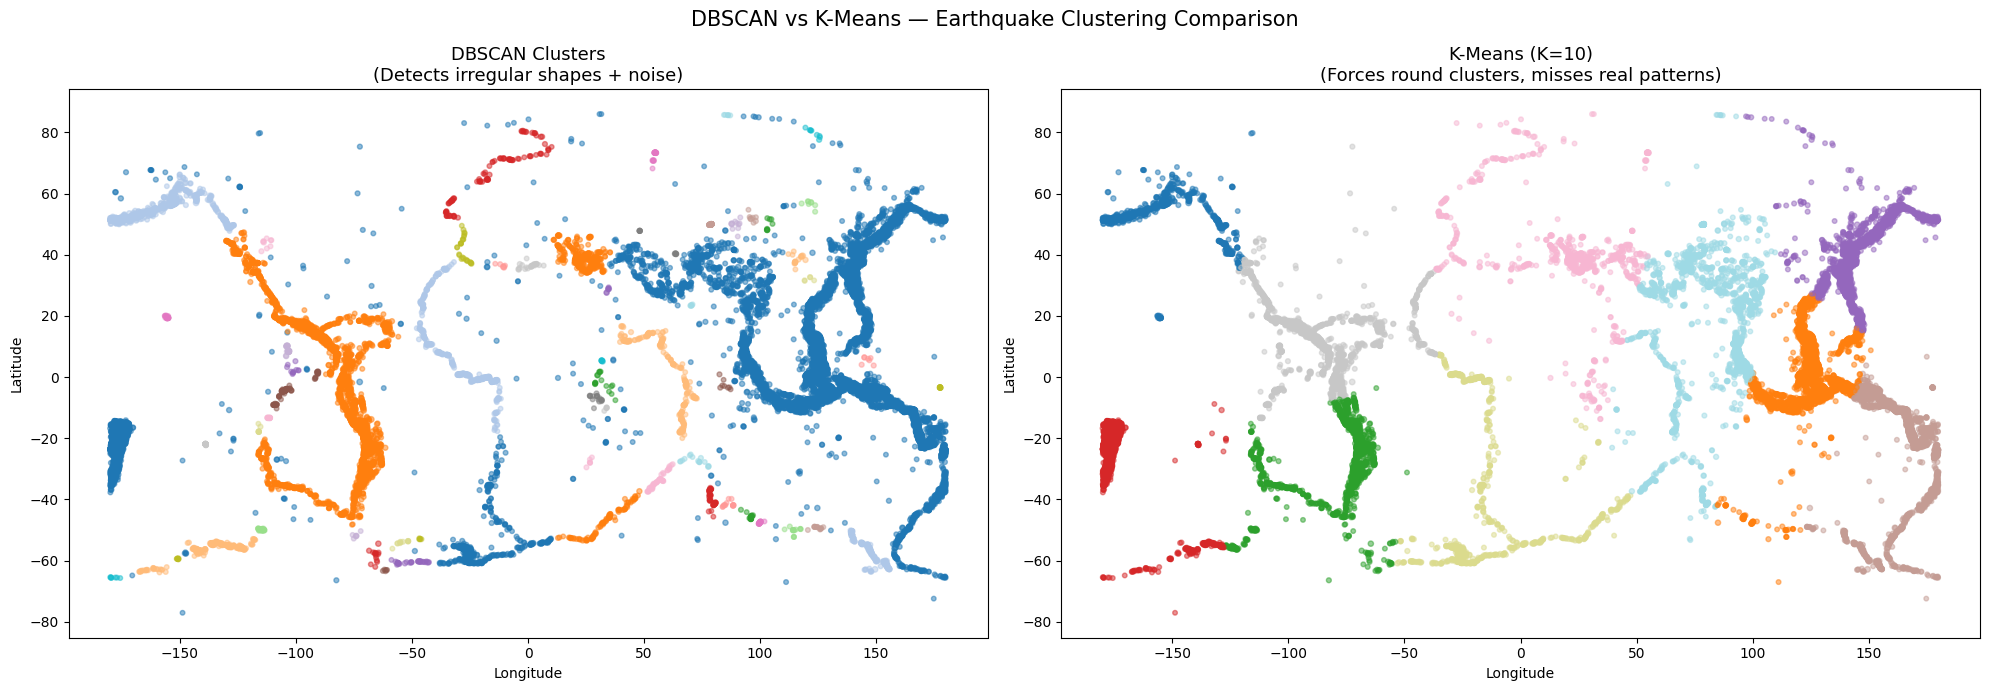

In [ ]:
from sklearn.cluster import KMeans

# Apply K-Means with K=10
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(coords)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# DBSCAN plot
axes[0].scatter(df['Longitude'], df['Latitude'],
                c=df['DBSCAN_Cluster'], cmap='tab20',
                s=df['Magnitude']*2, alpha=0.5)
axes[0].set_title('DBSCAN Clusters\n(Detects irregular shapes + noise)', fontsize=13)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# K-Means plot
axes[1].scatter(df['Longitude'], df['Latitude'],
                c=df['KMeans_Cluster'], cmap='tab20',
                s=df['Magnitude']*2, alpha=0.5)
axes[1].set_title('K-Means (K=10)\n(Forces round clusters, misses real patterns)', fontsize=13)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('DBSCAN vs K-Means — Earthquake Clustering Comparison', fontsize=15)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


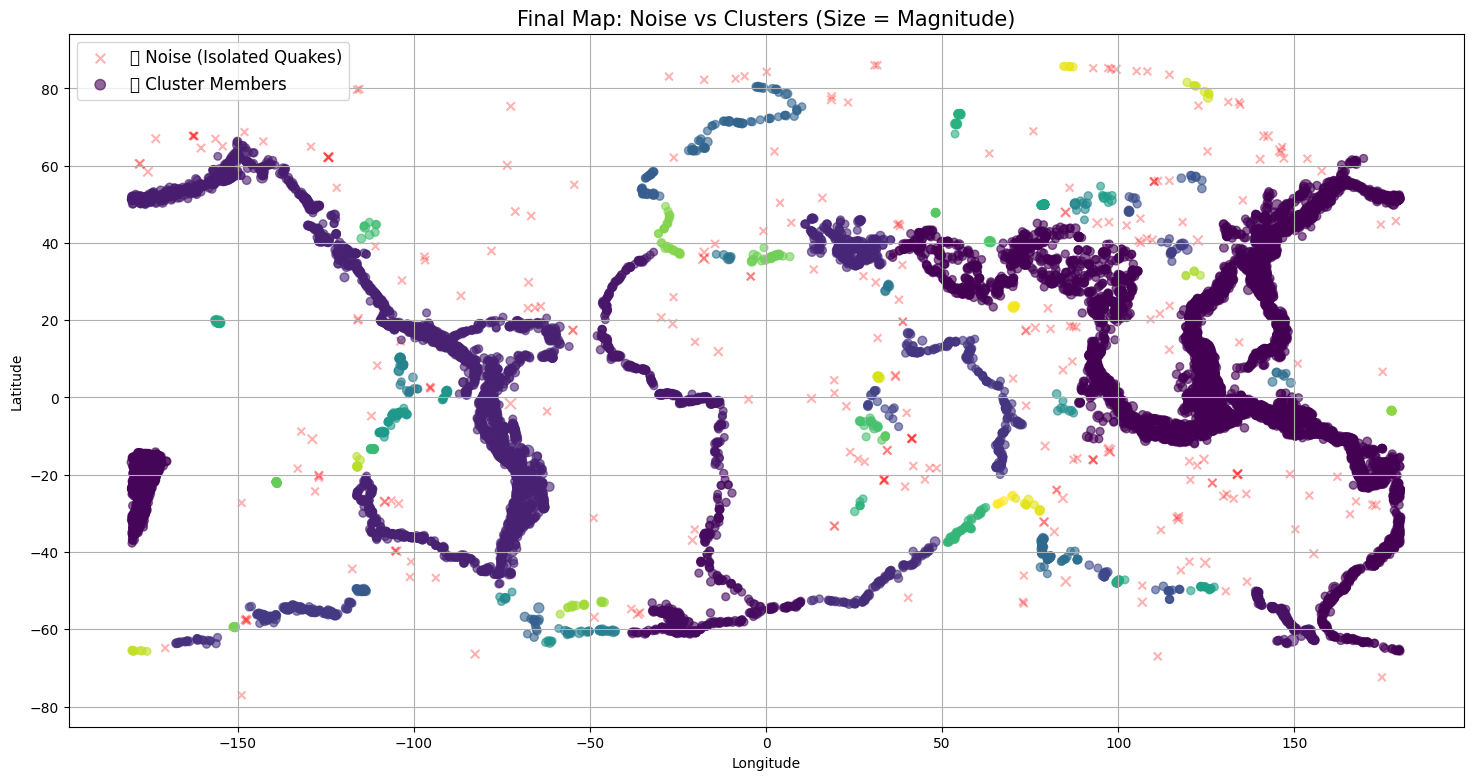


📌 PROJECT SUMMARY
Total Earthquakes Analysed : 23412
Clusters Detected (DBSCAN) : 66
Isolated Noise Points      : 266
Noise Percentage           : 1.14%


In [ ]:
# Final: noise vs clusters with magnitude as size
plt.figure(figsize=(18, 9))

noise = df[df['DBSCAN_Cluster'] == -1]
clusters = df[df['DBSCAN_Cluster'] != -1]

plt.scatter(noise['Longitude'], noise['Latitude'],
            c='red', s=noise['Magnitude']**2,
            alpha=0.3, label='🔴 Noise (Isolated Quakes)', marker='x')

plt.scatter(clusters['Longitude'], clusters['Latitude'],
            c=clusters['DBSCAN_Cluster'], cmap='viridis',
            s=clusters['Magnitude']**2,
            alpha=0.6, label='🟢 Cluster Members')

plt.title('Final Map: Noise vs Clusters (Size = Magnitude)', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

print("\n📌 PROJECT SUMMARY")
print(f"Total Earthquakes Analysed : {len(df)}")
print(f"Clusters Detected (DBSCAN) : {n_clusters}")
print(f"Isolated Noise Points      : {n_noise}")
print(f"Noise Percentage           : {round(n_noise/len(df)*100, 2)}%")